# Convolution Tutorial Series — Part 2: Padding

In [1]:
from IPython.display import Video

# Replace with the actual path to your video in the Kaggle input directory
video_path = '/kaggle/input/datasets/massimilianoghiotto/neurogolf-convseries-part2-supportvideo/PaddingTutorial.mp4'

Video(video_path, width=800, height=450, embed=True)

**Goal:** Understand why padding matters — and how to choose the right amount. This is the second episode in a series that we want to create, covering all the attributes of the ONNX Conv function, in this notebook we will cover the **padding** attribute. We will explain these as simply as possible, using some tasks as examples. The first episode of the serie can be found [here](https://www.kaggle.com/code/massimilianoghiotto/convolution-series-part-1). We will explain these as simply as possible, using some tasks as examples, similar to this [notebook](https://www.kaggle.com/code/massimilianoghiotto/best-public-6066-58-eda-111) that we made and EDA notebooks made by @cdeotte.

**Task (ARC 258):**
1. **Blue (1) stays where it is.**
2. **A Red (2) appears wherever a Black (0) cell has Blue both to its immediate left AND right.**
3. **Everything else stays Black.**

**Score formula:** `Points = max(1.0, 25.0 - log(Mem_bytes + Params))`

**Our result:** Mem=0, Params=310, **19.263 points**

**The idea:** The rule is horizontal-only, so the kernel is **1×3** (no vertical extent).

In [2]:
!pip install -q numpy==2.4.4 2>/dev/null
!pip install -q onnx==1.21.0 2>/dev/null
!pip install -q onnxruntime==1.24.4 2>/dev/null
!pip install -q onnx-tool==1.0.1 2>/dev/null

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 79.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 80.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.2/56.2 kB 1.5 MB/s eta 0:00:00


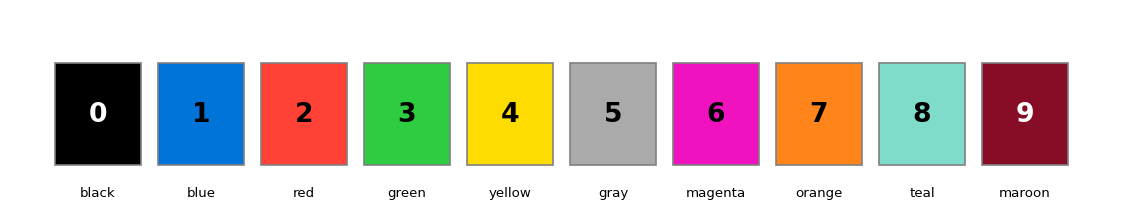

In [3]:
import json, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import onnx
from onnx import helper, TensorProto
import onnxruntime as ort

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120

arc_colors = [
    '#000000',  # 0: black
    '#0074D9',  # 1: blue
    '#FF4136',  # 2: red
    '#2ECC40',  # 3: green
    '#FFDC00',  # 4: yellow
    '#AAAAAA',  # 5: gray
    '#F012BE',  # 6: magenta
    '#FF851B',  # 7: orange
    '#7FDBCA',  # 8: teal
    '#870C25',  # 9: maroon
]
color_names = ['black','blue','red','green','yellow','gray','magenta','orange','teal','maroon']

def plot_arc_grid(grid, ax, title=''):
    H, W = len(grid), len(grid[0])
    img = np.zeros((H, W, 3), dtype=np.uint8)
    for r in range(H):
        for c in range(W):
            hex_c = arc_colors[grid[r][c]].lstrip('#')
            img[r,c] = [int(hex_c[i:i+2], 16) for i in (0, 2, 4)]
    ax.imshow(img, interpolation='nearest')
    ax.set_xticks([]); ax.set_yticks([])
    if title: ax.set_title(title, fontsize=10, fontweight='bold')
    for r in range(H+1): ax.axhline(r-0.5, color='gray', lw=0.5, alpha=0.3)
    for c in range(W+1): ax.axvline(c-0.5, color='gray', lw=0.5, alpha=0.3)

fig, ax = plt.subplots(figsize=(12, 2))
for i, (c, nm) in enumerate(zip(arc_colors, color_names)):
    ax.add_patch(patches.Rectangle((i*1.2, 0), 1, 1, facecolor=c, edgecolor='gray', lw=1))
    ax.text(i*1.2+0.5, 0.5, str(i), ha='center', va='center', fontsize=16, fontweight='bold',
            color='white' if i in [0,9] else 'black')
    ax.text(i*1.2+0.5, -0.2, nm, ha='center', va='top', fontsize=8)
ax.set_xlim(-0.5, 12.5)
ax.set_ylim(-0.3, 1.5)
ax.axis('off')
plt.show()

# 1. Task 258 Examples

The rule: **Red fills the gap between two Blues.** A lone Blue just stays Blue. A Black cell only becomes Red if it has Blue to **both** its immediate left and right.

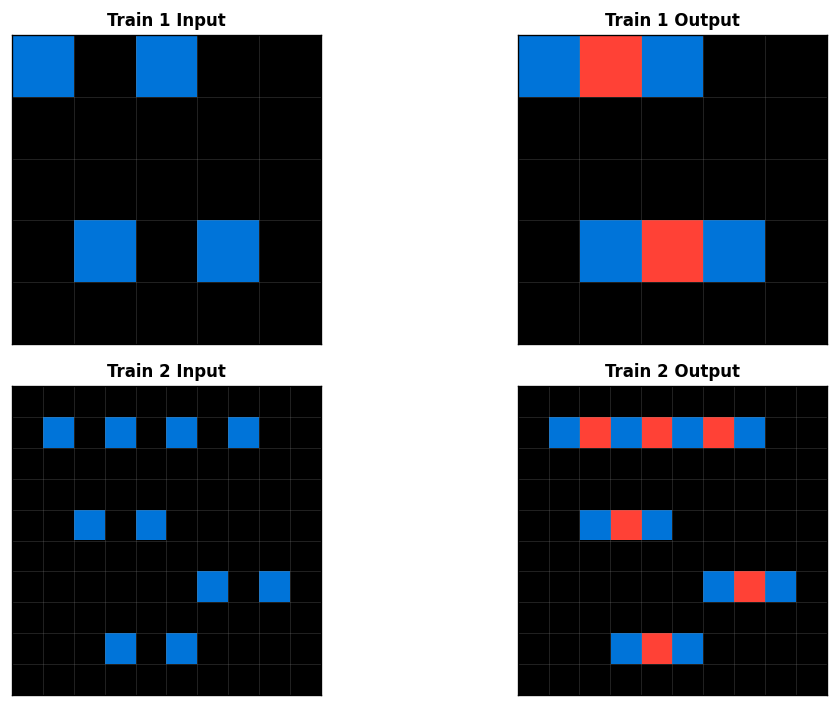

Notice: Blue at edges does NOT create Red outside itself.
Red only appears at Black cells sandwiched between two Blues.


In [4]:
with open('/kaggle/input/competitions/neurogolf-2026/task258.json') as f:
    task258 = json.load(f)

fig, axes = plt.subplots(2, 2, figsize=(10, 6))
plot_arc_grid(task258['train'][0]['input'], axes[0, 0], 'Train 1 Input')
plot_arc_grid(task258['train'][0]['output'], axes[0, 1], 'Train 1 Output')
plot_arc_grid(task258['train'][1]['input'], axes[1, 0], 'Train 2 Input')
plot_arc_grid(task258['train'][1]['output'], axes[1, 1], 'Train 2 Output')
plt.tight_layout()
plt.show()

print("Notice: Blue at edges does NOT create Red outside itself.")
print("Red only appears at Black cells sandwiched between two Blues.")

# 2. The 1×3 Horizontal Kernel

Since the rule only looks left and right (never up or down), we use a **1×3** kernel:

$$
\begin{bmatrix}
(-1) & (0) & (+1)
\end{bmatrix}
$$

- Offset `(0)` = the center pixel
- Offset `(-1)` = the **left** neighbor
- Offset `(+1)` = the **right** neighbor

### The Three Output Channels

We need three Conv output channels (Black, Blue, Red):

```
W[0, 0, 0, 1] = +4.0   # Black identity (center)
W[0, 1, 0, 0] = -2.0   # Black supressed by Blue on left
W[0, 1, 0, 2] = -2.0   # Black supressed by Blue on right

W[1, 1, 0, 1] = +2.0   # Blue identity (center)

W[2, 1, 0, 0] = +2.0   # Red votes from Blue on left
W[2, 1, 0, 2] = +2.0   # Red votes from Blue on right
```

And biases:
```
B = [-1.0, -1.0, -3.0, 0.0, 0.0, ..., 0.0]
```

| Channel | Weights | Bias | What it computes |
|---------|---------|------|------------------|
| **Black (0)** | $+4.0\cdot A_c$ $-2.0\cdot B_{l}$ $-2.0\cdot B_{r}$ | $-1.0$ | Stays Black unless surrounded by Blues |
| **Blue (1)** | $+2.0\cdot B_c$ | $-1.0$ | Stays Blue if center is Blue |
| **Red (2)** | $+2.0\cdot B_l$ $+2.0\cdot B_r$ | $-3.0$ | Fires only if Blue on BOTH sides |

Where $A_c$ is 1 if the center pixel of the convolution is black else it is 0. Similarly $B_c, B_l, B_r$ are 1 if, respectively, the center/left/right pixel is Blue, else 0.

### The Threshold Trick

The Red channel uses the bias as a **threshold**:
- One Blue neighbor: $2.0 - 3.0 = -1.0$ → **no Red**
- Two Blue neighbors: $4.0 - 3.0 = +1.0$ → **Red fires**

**A single Conv layer can't express "if A AND B", but bias-thresholding gives us the same effect!** Each weight contributes *half* the needed activation, and the bias sets the midpoint.

The Black channel does the *opposite*: it starts at $+4.0$ (identity), but each Blue neighbor subtracts $-2.0$. If surrounded by Blues ($4.0 - 4.0 = 0$), Black loses to Red ($+1.0$).

# 3. Padding
Padding is the process of adding extra pixels (usually zeros) around the border of an input image or feature map before applying a convolutional filter. It prevents the output feature map from shrinking and ensures the convolutional filter processes the edge pixels equally.

In Part 1, we used a 3×3 kernel with `pads=[1, 1, 1, 1]`. We padded **all four sides** because the kernel extends in all directions.

Here the kernel is **1×3** — it only extends horizontally. We should only pad **left and right**: `pads=[0, 1, 0, 1]`.

$$\text{pads} = [\underbrace{0}_{\text{top}}, \underbrace{1}_{\text{left}}, \underbrace{0}_{\text{bottom}}, \underbrace{1}_{\text{right}}]$$

Imagine a Blue pixel at **column 0** (left edge). The kernel centered there looks at column -1 — which doesn't exist. With `pads=[0, 1, 0, 1]`, the Conv engine creates a **virtual column of zeros** to the left. That zero means "no Blue" — so the Red threshold isn't met (only one Blue neighbor to the right).

**Without padding**, the output shrinks and the Blue at column 0 gets truncated — its influence on its right neighbor is lost.

Now we make a figure with three different padding values and we see the effect on the output.

2026-06-02 09:14:49.947690072 [W:onnxruntime:, graph.cc:122 MergeShapeInfo] Error merging shape info for output. 'output' source:{1,10,30,28} target:{1,10,30,30}. Falling back to lenient merge.
2026-06-02 09:14:49.961746621 [W:onnxruntime:, graph.cc:122 MergeShapeInfo] Error merging shape info for output. 'output' source:{1,10,32,30} target:{1,10,30,30}. Falling back to lenient merge.


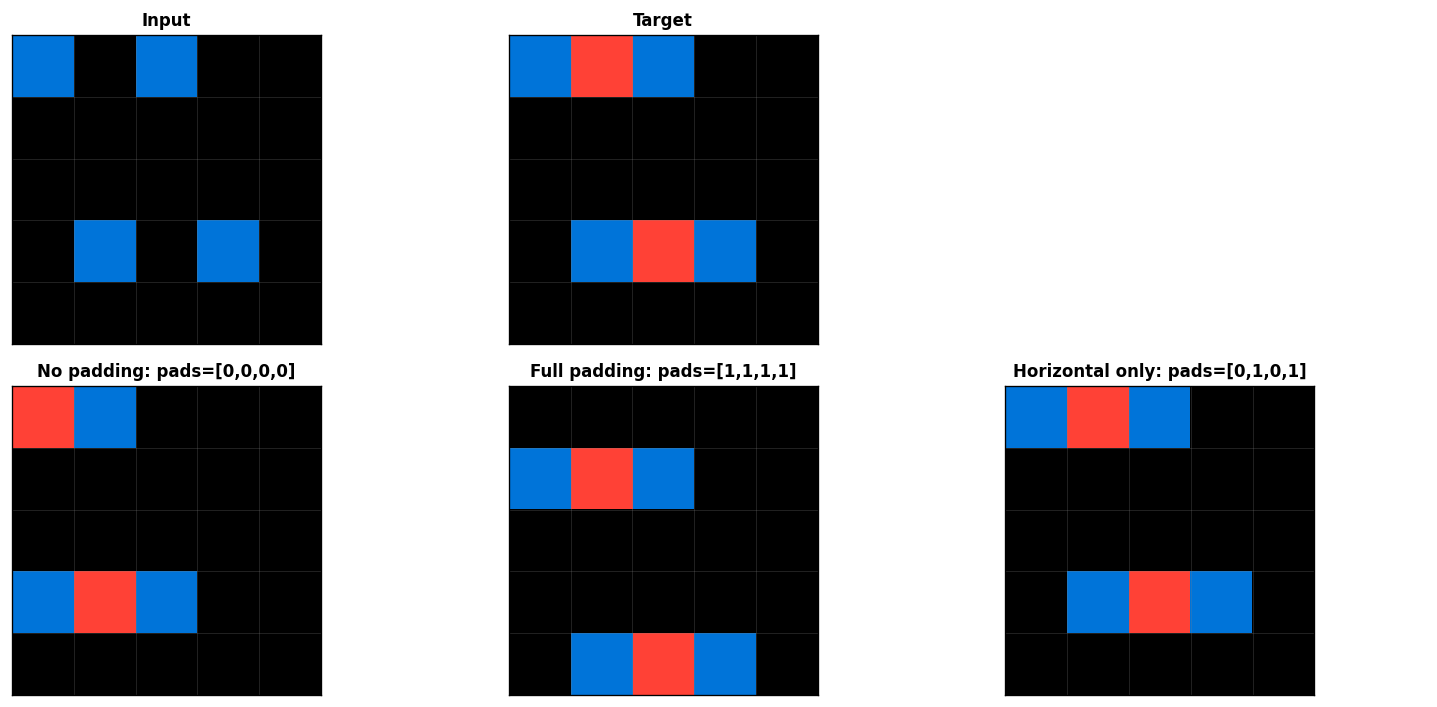

No padding: output shrinks to 28-wide; Blues at edges lose influence.
Full padding: works but wastes vertical computation.
Horizontal only: correct — output is 30×30, edges behave correctly.


In [5]:
def build_model_with_padding(pads, kernel_shape=[1, 3]):
    W = np.zeros((10, 5, 1, 3), dtype=np.float32)  # groups=2
    W[0, 0, 0, 1] = 4.0
    W[0, 1, 0, 0] = -2.0
    W[0, 1, 0, 2] = -2.0
    W[1, 1, 0, 1] = 2.0
    W[2, 1, 0, 0] = 2.0
    W[2, 1, 0, 2] = 2.0

    B = np.array([-1.0, -1.0, -3.0, -1.0, -1.0,
                  -1.0, -1.0, -1.0, -1.0, -1.0], dtype=np.float32)

    inp = helper.make_tensor_value_info('input', TensorProto.FLOAT, [1, 10, 30, 30])
    out = helper.make_tensor_value_info('output', TensorProto.FLOAT, [1, 10, 30, 30])
    W_init = helper.make_tensor('W', TensorProto.FLOAT, [10, 5, 1, 3], W.flatten())
    B_init = helper.make_tensor('B', TensorProto.FLOAT, [10], B.tolist())
    node = helper.make_node('Conv', ['input', 'W', 'B'], ['output'],
                            kernel_shape=kernel_shape, pads=pads, group=2)
    graph = helper.make_graph([node], 'task258', [inp], [out], [W_init, B_init])
    return helper.make_model(graph, opset_imports=[helper.make_operatorsetid('', 11)])

def run_and_get_pred(model, grid):
    oh = np.zeros((1, 10, 30, 30), dtype=np.float32)
    for r in range(len(grid)):
        for c in range(len(grid[0])):
            oh[0, grid[r][c], r, c] = 1.0
    sess = ort.InferenceSession(model.SerializeToString())
    out = sess.run(None, {'input': oh})[0]
    return np.argmax(out[0], axis=0)

# Pick a test input with Blues at edges
test_grid = task258['train'][0]['input']
target = task258['train'][0]['output']
H, W = len(test_grid), len(test_grid[0])

# Three padding strategies
strategies = [
    ('No padding: pads=[0,0,0,0]', [0, 0, 0, 0]),
    ('Full padding: pads=[1,1,1,1]', [1, 1, 1, 1]),
    ('Horizontal only: pads=[0,1,0,1]', [0, 1, 0, 1]),
]

fig, axes = plt.subplots(2, 3, figsize=(13, 6))
plot_arc_grid(test_grid, axes[0, 0], 'Input')
plot_arc_grid(target, axes[0, 1], 'Target')
axes[0, 2].axis('off')

for i, (label, pads) in enumerate(strategies):
    m = build_model_with_padding(pads)
    pred = run_and_get_pred(m, test_grid)
    plot_arc_grid(pred[:H, :W], axes[1, i], label)

plt.tight_layout()
plt.show()

print("No padding: output shrinks to 28-wide; Blues at edges lose influence.")
print("Full padding: works but wastes vertical computation.")
print("Horizontal only: correct — output is 30×30, edges behave correctly.")

The Conv `pads` parameter takes 4 values: `[top, left, bottom, right]`.

| pads | Output shape | Problem |
|------|-------------|--------|
| `[0,0,0,0]` (valid) | Shrinks to **30×28** | A Blue at column 0 has its left neighbor padded — but more importantly, a Black at column 28 is missing its right neighbor check. The output also shrinks because no padding means the kernel can't slide fully to the edges. |
| `[1,1,1,1]` (same) | Upscale to **32×30** | This visually works, but the final output has two extra empty rows. |
| `[0,1,0,1]` (correct) | Stays **30×30** | Pads only where the kernel extends. |

### The Output Shape Formula

For a convolution with:
- Input size: $(W, H)$
- Kernel size: $(k_w, k_h)$
- Padding: $(p_{top}, p_{left}, p_{bottom}, p_{right})$
- Stride: $(s_w, s_h)=(1,1)$ (we will cover stride in the next chapter, at the moment you can ignore it)

The output width is:

$$W_{\text{out}} = \frac{W + p_{\text{left}} + p_{\text{right}} - k_w}{s_w} + 1$$

The same hold for the height:

$$H_{\text{out}} = \frac{H + p_{\text{top}} + p_{\text{bottom}} - k_h}{s_h} + 1$$

For our 30-wide input with a 1×3 kernel:

| pads | $p_{\text{left}}+p_{\text{right}}$ | $W_{\text{out}}$ | $p_{\text{top}}+p_{\text{bottom}}$ | $H_{\text{out}}$ |
|------|------|------|------|------|
| `[0,0,0,0]` | 0 | $\frac{30 + 0 - 3}{1} + 1 = 28 \neq 30$ | 0 | $\frac{30 + 0 - 1}{1} + 1 = 30$ |
| `[1,1,1,1]` | 2 | $\frac{30 + 2 - 3}{1} + 1 = 30$ | 0 | $\frac{30 + 2 - 1}{1} + 1 = 32$ |
| `[0,1,0,1]` | 2 | $\frac{30 + 2 - 3}{1} + 1 = 30$ | 0 | $\frac{30 + 0 - 1}{1} + 1 = 30$ |

In [6]:
# Replace with the actual path to your video in the Kaggle input directory
video_path = '/kaggle/input/datasets/massimilianoghiotto/neurogolf-convseries-part2-supportvideo/PaddingTutorial.mp4'

Video(video_path, width=800, height=450, embed=True)

# 4. The Trained Model
We now implement and verify our model.

In [7]:
W = np.zeros((10, 10, 1, 3), dtype=np.float32)
W[0, 0, 0, 1] = 4.0
W[0, 1, 0, 0] = -2.0
W[0, 1, 0, 2] = -2.0
W[1, 1, 0, 1] = 2.0
W[2, 1, 0, 0] = 2.0
W[2, 1, 0, 2] = 2.0

B = np.array([-1.0, -1.0, -3.0, -1.0, -1.0,
              -1.0, -1.0, -1.0, -1.0, -1.0], dtype=np.float32)

inp = helper.make_tensor_value_info('input', TensorProto.FLOAT, [1, 10, 30, 30])
out = helper.make_tensor_value_info('output', TensorProto.FLOAT, [1, 10, 30, 30])
W_init = helper.make_tensor('W', TensorProto.FLOAT, [10, 10, 1, 3], W.flatten().tolist())
B_init = helper.make_tensor('B', TensorProto.FLOAT, [10], B.tolist())
node = helper.make_node('Conv', ['input', 'W', 'B'], ['output'],
                        kernel_shape=[1, 3], pads=[0, 1, 0, 1])
graph = helper.make_graph([node], 'task258', [inp], [out], [W_init, B_init])
model258 = helper.make_model(graph, opset_imports=[helper.make_operatorsetid('', 11)])
print(f"Model built: groups=2, weights shape {W.shape}, params={W.size + B.size}")

Model built: groups=2, weights shape (10, 10, 1, 3), params=310


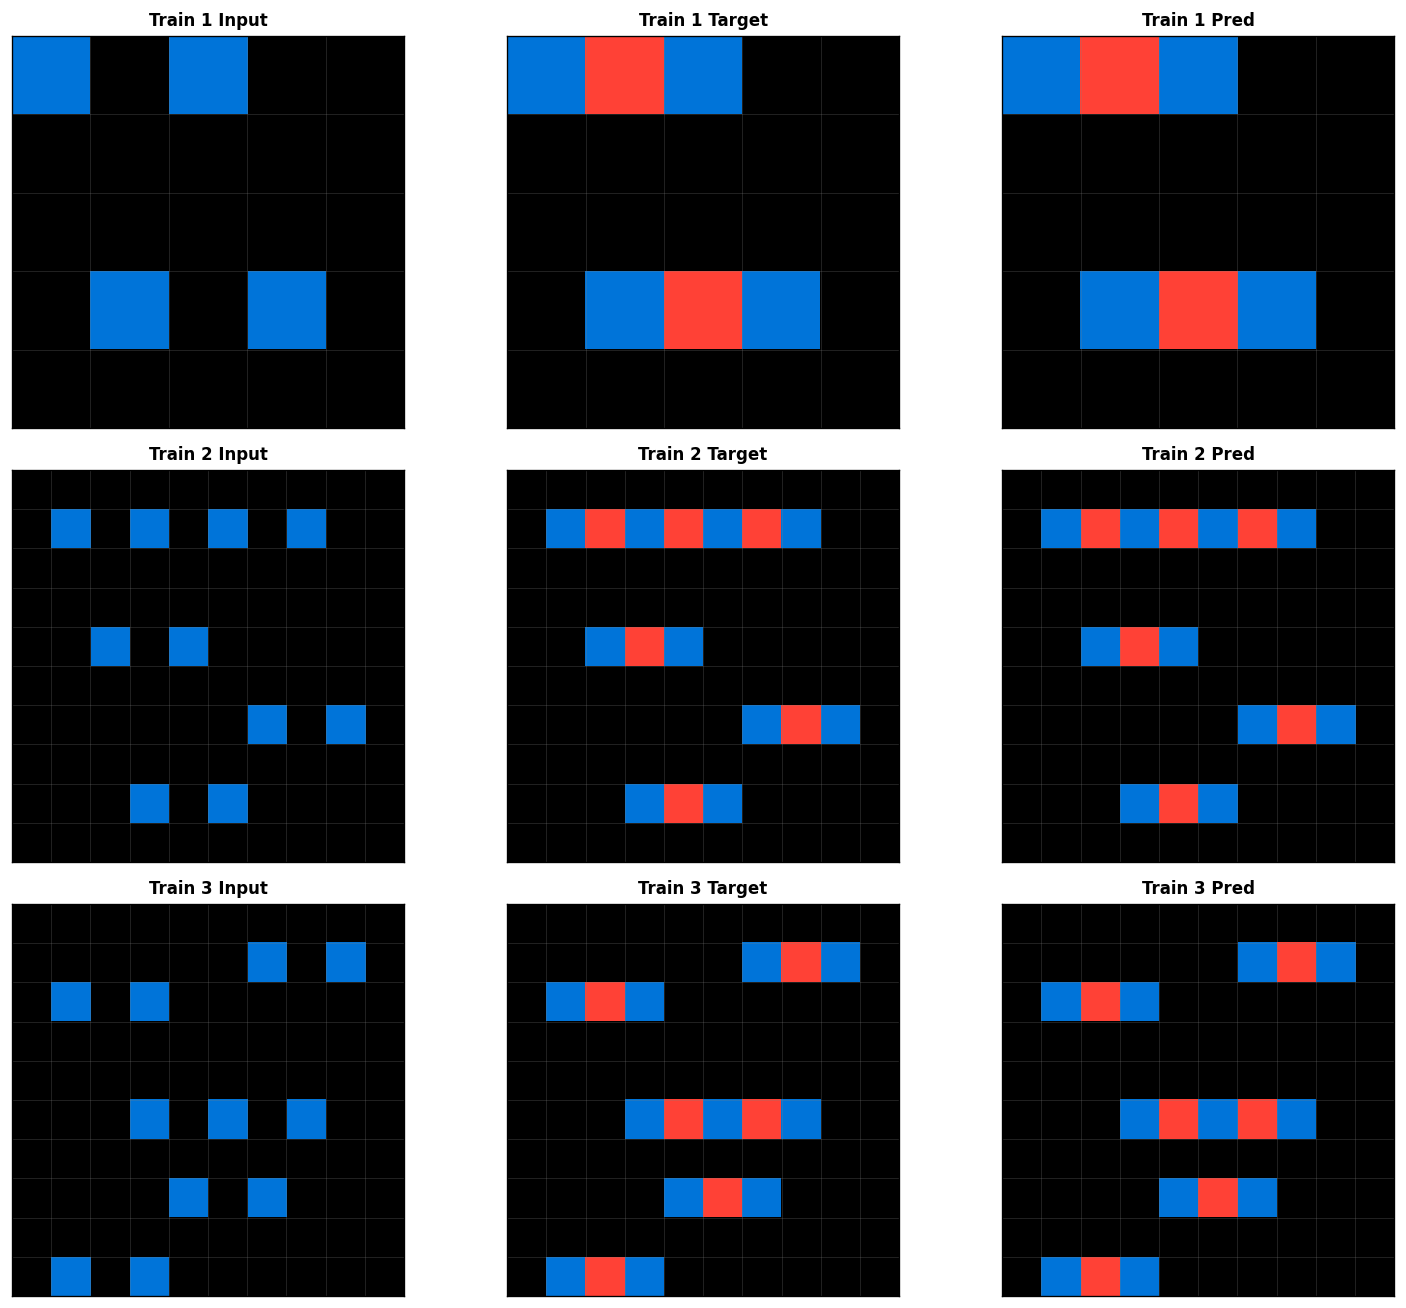

Results on ARC-AGI examples: 4 pass, 0 fail
Results on ARC-GEN examples: 262 pass, 0 fail

Your network IS READY for submission!

Performance stats (memory values reported here are approximate):
Name    Type    Forward_MACs    FPercent    Memory    MPercent      Params  PPercent    InShape     OutShape
------  ------  --------------  ----------  --------  ----------  --------  ----------  ----------  ----------
Conv_0  Conv    279,000         100.00%     37,240    100.00%          310  100.00%     1x10x30x30  1x10x30x30
Total   _       279,000         100%        37,240    100%             310  100%        _           _

It appears to require 0 bytes + 310 params, yielding 19.263 points.

Next steps:
 * Click the link below to download task258.onnx onto your local machine.
 * Create a zip file containing that network along with all others.
 * Submit that zip file to the Kaggle competition so that it can be officially scored.



/kaggle/working/task258.onnx

In [8]:
# Test on all train examples
fig, axes = plt.subplots(3, 3, figsize=(13, 11))
for i in range(3):
    inp = task258['train'][i]['input']
    target = task258['train'][i]['output']
    H, W = len(inp), len(inp[0])
    oh = np.zeros((1, 10, 30, 30), dtype=np.float32)
    for r in range(H):
        for c in range(W):
            oh[0, inp[r][c], r, c] = 1.0
    sess = ort.InferenceSession(model258.SerializeToString())
    out = sess.run(None, {'input': oh})[0]
    pred = np.argmax(out[0], axis=0)
    plot_arc_grid(inp, axes[i, 0], f'Train {i+1} Input')
    plot_arc_grid(target, axes[i, 1], f'Train {i+1} Target')
    plot_arc_grid(pred[:H, :W], axes[i, 2], f'Train {i+1} Pred')
plt.tight_layout()
plt.show()

# Verify with official checker
import sys
sys.path.append("/kaggle/input/competitions/neurogolf-2026/neurogolf_utils")
from neurogolf_utils import *
passed = verify_network(model258, 258, task258)

# Summary

- **The rule:** Red fills gaps of exactly 1 between two Blues — it does NOT appear at the edges of a single Blue.
- **The threshold trick:** A single Conv layer can't do "if A AND B" natively, but the bias threshold turns `Blue[left] + Blue[right]` into a logical AND.
- **Black removal:** The Black channel uses the same Blue-detection weights (negative) to suppress itself where Red should appear.
- **Pad correctly:** A 1×3 kernel only needs left+right padding (`pads=[0,1,0,1]`).

In [9]:
import shutil
import os
import zipfile

# --- CONFIGURATION ---
SOURCE_FOLDER = '/kaggle/input/datasets/massimilianoghiotto/neurogolf2026-6208/'
OUTPUT_ZIP = '/kaggle/working/submission.zip'

# Package the ZIP (Ensuring files are at the root)
with zipfile.ZipFile(OUTPUT_ZIP, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(SOURCE_FOLDER):
        for file in files:
            if file.endswith('.onnx'):
                file_path = os.path.join(root, file)
                zipf.write(file_path, os.path.relpath(file_path, SOURCE_FOLDER))

### **This is the best that we are able to do for the moment, if anyone has any suggestion, please write it in the comments, we are happy to have some brainstorning between people.**